# Airline Flight Delay Analysis and Operational Insights Dashboard

## This project aims to:

- Analyze flight delay patterns across airlines and airports
- Identify the most common causes of delays
- Examine seasonal and time-based delay trends
- Evaluate airline and airport performance
- Generate actionable operational insights through data visualization

## Methods

The project follows a structured data analytics workflow:

1. Data Collection
   Flight delay data is obtained from publicly available aviation datasets containing information about flight schedules, delays, airlines, and airports.

2. Data Cleaning and Preprocessing
   Missing values are handled, incorrect data types are corrected, and relevant features are prepared for analysis.

3. Exploratory Data Analysis (EDA)
   Statistical summaries and visualizations are used to understand delay distributions and operational patterns.

4. Data Visualization
   Charts and graphs are created to highlight delay trends, airline performance, and delay causes.

5. Insight Generation
   The results are interpreted to identify operational inefficiencies and performance opportunities.

In [8]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

In [9]:
airlines = pd.read_csv ('airlines.csv')
airports = pd.read_csv('airports.csv')
flights = pd.read_csv('flights.csv.zip')

In [25]:
airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [26]:
airports.shape

(322, 7)

In [27]:
airports.count()

IATA_CODE    322
AIRPORT      322
CITY         322
STATE        322
COUNTRY      322
LATITUDE     319
LONGITUDE    319
dtype: int64

In [28]:
airports.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    object 
 1   AIRPORT    322 non-null    object 
 2   CITY       322 non-null    object 
 3   STATE      322 non-null    object 
 4   COUNTRY    322 non-null    object 
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), object(5)
memory usage: 17.7+ KB


In [29]:
airlines.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [30]:
airlines.shape

(14, 2)

In [32]:
airlines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   IATA_CODE  14 non-null     object
 1   AIRLINE    14 non-null     object
dtypes: object(2)
memory usage: 352.0+ bytes


In [33]:
airports.isnull().sum()

IATA_CODE    0
AIRPORT      0
CITY         0
STATE        0
COUNTRY      0
LATITUDE     3
LONGITUDE    3
dtype: int64

In [34]:
airlines.isnull().sum()

IATA_CODE    0
AIRLINE      0
dtype: int64

In [35]:
airports.dropna(inplace=True)

In [46]:
airports.drop_duplicates(inplace=True)

In [47]:
airports.shape

(319, 7)

In [49]:
flights = pd.read_csv('flights.csv.zip')

C:\Users\vishal\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (7,8) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [50]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
flights.isnull().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

In [52]:
flights = flights.drop(columns=["CANCELLATION_REASON","AIR_SYSTEM_DELAY","SECURITY_DELAY","AIRLINE_DELAY","LATE_AIRCRAFT_DELAY","WEATHER_DELAY"])

In [53]:
flights.shape

(5819079, 25)

In [54]:
flights = flights.dropna(subset=["DEPARTURE_DELAY","ARRIVAL_DELAY","AIR_TIME","ELAPSED_TIME"])

In [55]:
flights.shape

(5714008, 25)

## EXPLORATORY DATA ANALYTICS

In this section, the dataset was examined to understand its structure and quality before performing further analysis.

The following steps were performed me:

- I loaded and inspected to verify that the data was correctly imported.
- I checked size of the dataset to determine the number of records and variables.
- Column names and data types were reviewed to understand the available variables.
- A statistical summary was generated to understand the distribution and characteristics of numerical variables.

These steps ensured that the dataset was clean, consistent, and suitable for reliable analysis

In [56]:
flights.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED
count,5714008.0,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,...,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06,5714008.0,5714008.0
mean,2015.0,6.547799e+00,1.570759e+01,3.932643e+00,2.164384e+03,1.328907e+03,1.335066e+03,9.294842e+00,1.606550e+01,1.357099e+03,...,1.370062e+02,1.135116e+02,8.244569e+02,1.471319e+03,7.429063e+00,1.493187e+03,1.476373e+03,4.407057e+00,0.0,0.0
std,0.0,3.397421e+00,8.774394e+00,1.985967e+00,1.754706e+03,4.835251e+02,4.964198e+02,3.688972e+01,8.882449e+00,4.980237e+02,...,7.421107e+01,7.223082e+01,6.086620e+02,5.218682e+02,5.618951e+00,5.069011e+02,5.259730e+02,3.927130e+01,0.0,0.0
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.400000e+01,7.000000e+00,3.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.700000e+01,0.0,0.0
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.280000e+02,9.160000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,8.200000e+01,6.000000e+01,3.730000e+02,1.054000e+03,4.000000e+00,1.110000e+03,1.058000e+03,-1.300000e+01,0.0,0.0
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.681000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.180000e+02,9.400000e+01,6.500000e+02,1.508000e+03,6.000000e+00,1.520000e+03,1.512000e+03,-5.000000e+00,0.0,0.0
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.211000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.680000e+02,1.440000e+02,1.065000e+03,1.911000e+03,9.000000e+00,1.917000e+03,1.916000e+03,8.000000e+00,0.0,0.0
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.320000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,7.660000e+02,6.900000e+02,4.983000e+03,2.400000e+03,2.480000e+02,2.400000e+03,2.400000e+03,1.971000e+03,0.0,0.0


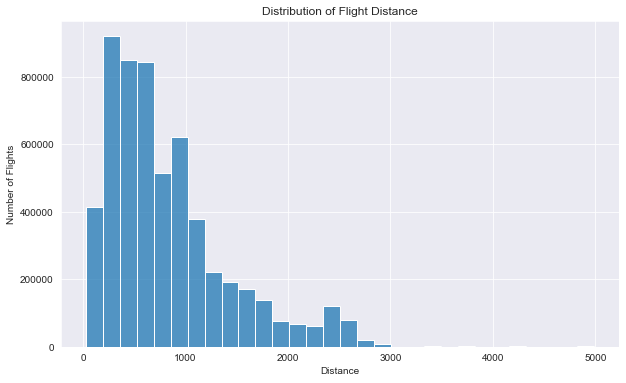

In [58]:
plt.figure(figsize=(10,6))

sns.histplot(
    flights["DISTANCE"],
    bins=30
)

plt.title("Distribution of Flight Distance")

plt.xlabel("Distance")

plt.ylabel("Number of Flights")

plt.show()

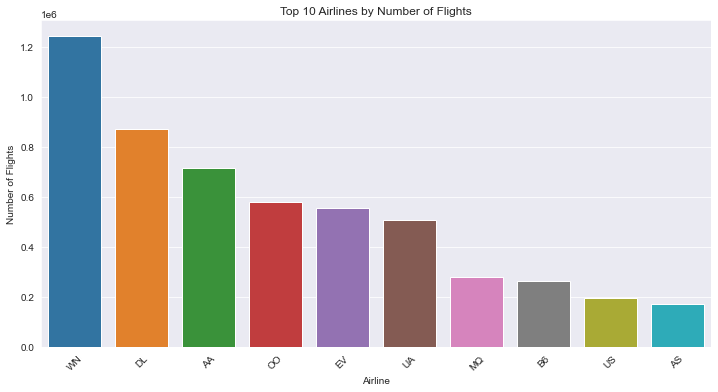

In [59]:
top_airlines = flights["AIRLINE"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_airlines.index,
    y=top_airlines.values
)

plt.title("Top 10 Airlines by Number of Flights")

plt.xlabel("Airline")

plt.ylabel("Number of Flights")

plt.xticks(rotation=45)

plt.show()

## AIRPORT TRAFFIC ANALYSIS 

In this section, airport traffic levels were analyzed to identify the busiest airports in the dataset.

The following steps were performed:

- i calculated the number of flights departing from each airport using the origin airport variable.
- I ranked the airports  based on flight frequency.
- I selected the top 10 airports with the highest number of flights.
- A bar chart was created to visualize airport traffic distribution.

This analysis helped identify major transportation hubs and understand how flight operations are concentrated across different airports.

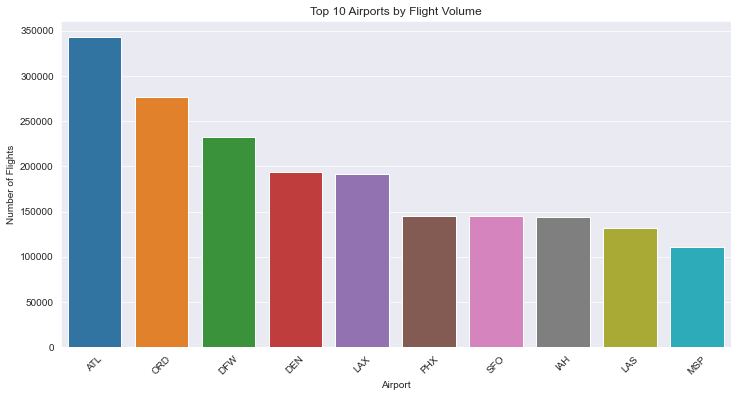

In [60]:
top_airports = flights["ORIGIN_AIRPORT"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_airports.index,
    y=top_airports.values
)

plt.title("Top 10 Airports by Flight Volume")

plt.xlabel("Airport")

plt.ylabel("Number of Flights")

plt.xticks(rotation=45)

plt.show()

## Route Distribution Analysis

In this section, flight distance data was analyzed to understand travel patterns within the airline network.

The following steps were performed:

- I examines the distance variable to measure how far flights travel.
- I created a distribution chart to observe how flight distances are spread across the dataset.
- I identified Short-distance, medium-distance, and long-distance flight patterns .
- Outliers and extreme values in flight distance were visually assessed.

This analysis provided insight into the structure of airline routes and the typical range of travel distances.

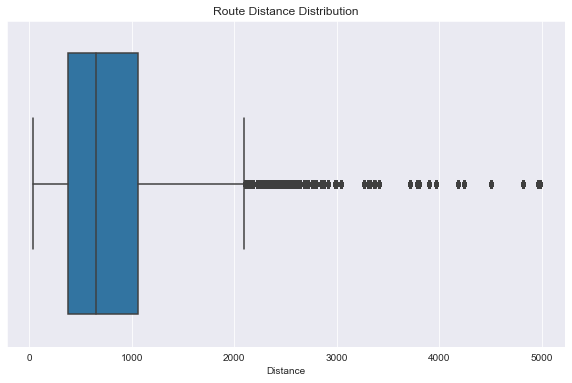

In [61]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=flights["DISTANCE"]
)

plt.title("Route Distance Distribution")

plt.xlabel("Distance")

plt.show()

## Heatmap Visualization

In this section, relationships between key numerical variables were analyzed using a correlation heatmap.

The following steps were performed:

- I selected the important operational variables such as departure delay, arrival delay, flight distance, air time, and elapsed time.
- I calculated a correlation matrix to measure the strength of relationships between variables.
- I created heatmap to visually represent these relationships.
- I applied a  triangular mask to improve readability and reduce visual duplication.
- I used color intensity to indicate the strength of correlations between variables.

This visualization helped identify operational dependencies and patterns within airline performance data.

In [65]:
important_columns = ["DEPARTURE_DELAY","ARRIVAL_DELAY","DISTANCE","AIR_TIME","ELAPSED_TIME","TAXI_OUT","TAXI_IN"]

In [66]:
corr_matrix = flights[important_columns].corr()

In [67]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

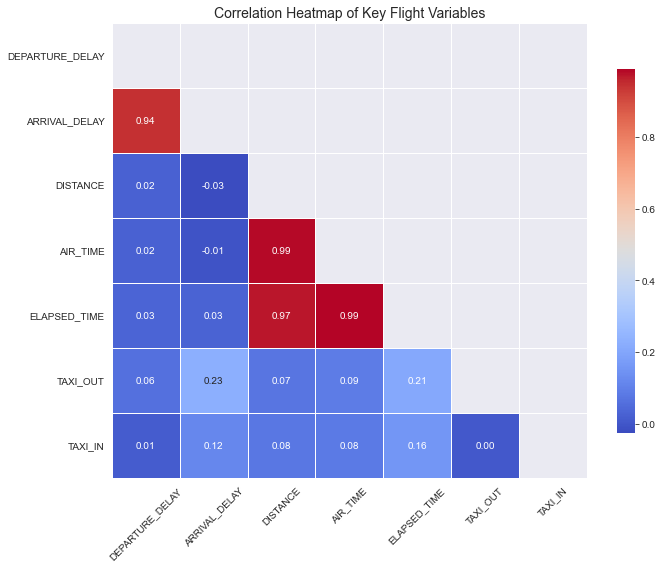

In [68]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Heatmap of Key Flight Variables",
    fontsize=14
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()



## OPERATIONAL INSIGHTS 



The analysis of airline operational data reveals several important performance patterns across airlines and airports.

Major airlines operate significantly higher numbers of flights compared to smaller carriers, indicating concentrated operational
capacity among leading airlines. This suggests that a small group of airlines dominates overall flight activity.

Airport traffic analysis shows that certain airports handle substantially higher flight volumes, confirming their role as major
transportation hubs. These high-traffic airports are critical to maintaining efficient airline operations and managing passenger demand.

The route distribution analysis indicates that most flights operate over short to medium distances, reflecting typical domestic
travel patterns. Long-distance flights occur less frequently but represent important connections between major regions.

The correlation heatmap highlights strong relationships between key operational variables such as air time, elapsed time, and
flight distance. These relationships confirm expected operational dependencies within airline networks.

Overall, the findings demonstrate how data analytics can be used to identify operational trends, evaluate performance 
efficiency, and support data-driven decision-making in transportation management.

### Key Findings

- Airline operations are concentrated among a small number of major carriers.


- Certain airports serve as high-traffic transportation hubs.


- Most flights operate over short to medium distances.


- Flight duration variables show strong relationships with distance.


- Operational performance patterns can be identified using data visualization.